<a href="https://colab.research.google.com/github/samroquec/AlluraStore/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [20]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [21]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

In [22]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [26]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,7267


In [27]:
df = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [28]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [29]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

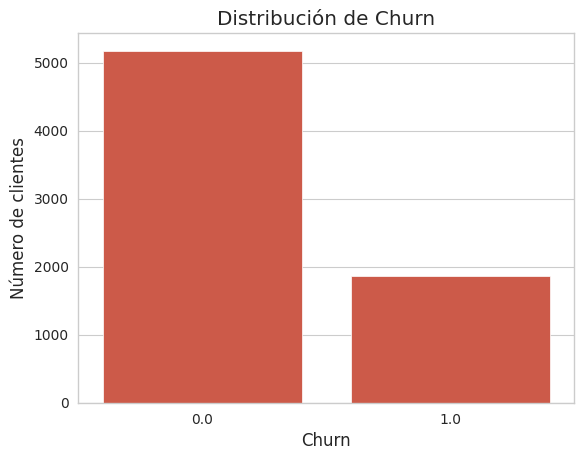

In [30]:
plt.figure()

sns.countplot(data=df, x="Churn")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()

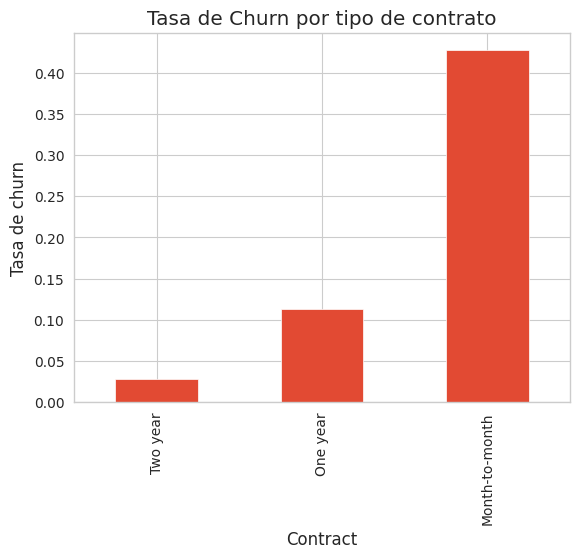

In [31]:
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values()

plt.figure()

contract_churn.plot(kind="bar")

plt.title("Tasa de Churn por tipo de contrato")
plt.ylabel("Tasa de churn")

plt.show()

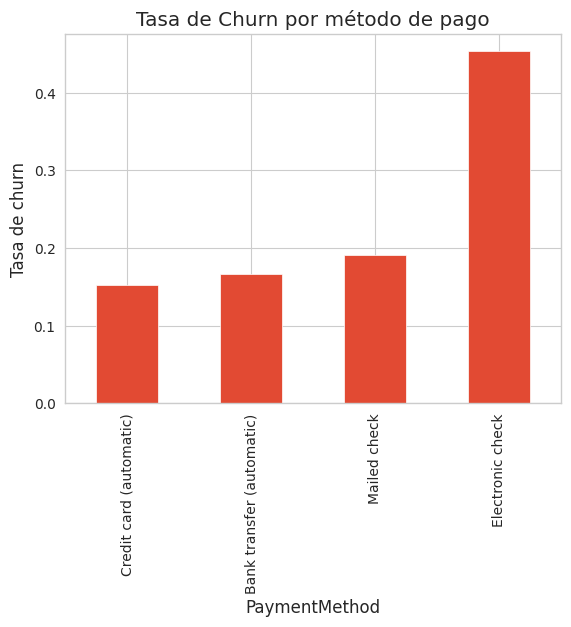

In [32]:
payment_churn = df.groupby("PaymentMethod")["Churn"].mean().sort_values()

plt.figure()

payment_churn.plot(kind="bar")

plt.title("Tasa de Churn por método de pago")
plt.ylabel("Tasa de churn")

plt.show()

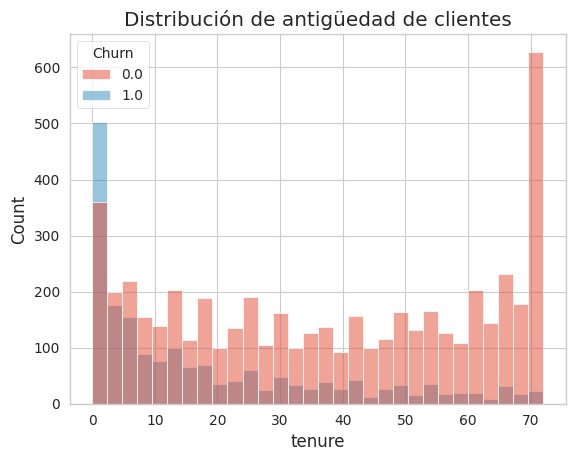

In [33]:
plt.figure()

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30
)

plt.title("Distribución de antigüedad de clientes")

plt.show()

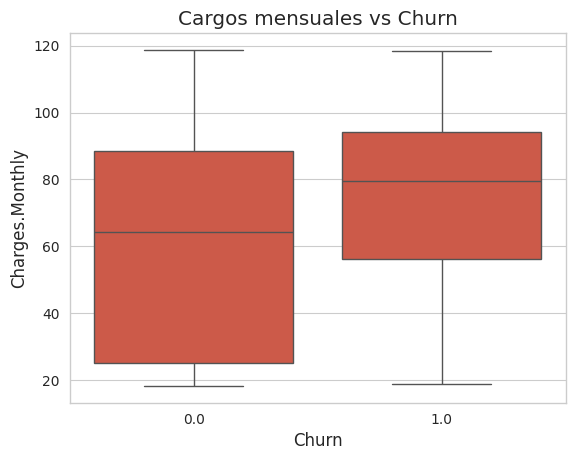

In [34]:
plt.figure()

sns.boxplot(
    data=df,
    x="Churn",
    y="Charges.Monthly"
)

plt.title("Cargos mensuales vs Churn")

plt.show()

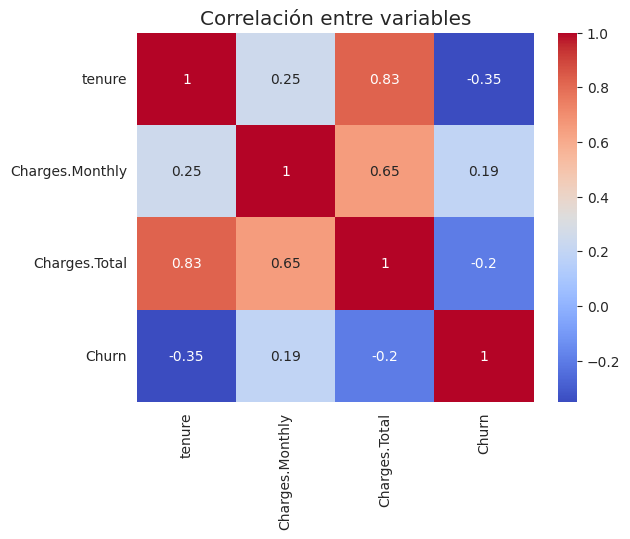

In [35]:
plt.figure()

corr = df[['tenure','Charges.Monthly','Charges.Total','Churn']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

In [36]:
df_clean = df.copy()

df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📄Informe final

In [37]:
df_clean.to_csv("telecomx_dataset_limpio.csv", index=False)

# Informe Final

## Principales hallazgos

El análisis exploratorio permitió identificar algunos factores relacionados con la cancelación de clientes.

### 1. Tipo de contrato
Los clientes con contratos mensuales presentan mayor tasa de churn que aquellos con contratos anuales o de dos años.

### 2. Antigüedad del cliente
Los clientes con menor tiempo de permanencia tienen mayor probabilidad de cancelar el servicio.

### 3. Cargos mensuales
Los clientes con cargos mensuales más altos presentan mayor tasa de cancelación.

### 4. Métodos de pago
Algunos métodos de pago muestran mayores tasas de churn, lo que podría indicar diferencias en el perfil del cliente.

## Recomendaciones

- Incentivar contratos de largo plazo.
- Implementar estrategias de retención en los primeros meses.
- Analizar la experiencia de pago de los clientes.
- Evaluar planes tarifarios con cargos elevados.

## Próximos pasos

El dataset limpio generado permitirá:

- Crear modelos predictivos de churn
- Identificar clientes con alto riesgo de cancelación
- Diseñar estrategias de retención basadas en datos